In [24]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer, AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.primitives import StatevectorSampler
from qiskit_ibm_runtime import SamplerV2
from qiskit_ibm_runtime.fake_provider import FakeKyiv


def deutsch_function(case: int): #Important function, implemented in cells below


    if case not in [1, 2, 3, 4]:
        raise ValueError("`case` must be 1, 2, 3, or 4.")

    f = QuantumCircuit(2)
    if case in [2, 3]:
        f.cx(0, 1)
    if case in [3, 4]:
        f.x(1)
    return f

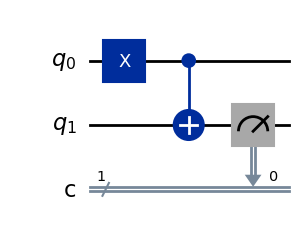

Noiseless: {'1': 1024}
Noisy: {'1': 1014, '0': 10}


In [28]:
case = 2

# -----------------------
# NOISELESS VERSION
# -----------------------

qc_ideal = QuantumCircuit(2, 1)

# Manually choose the input
qc_ideal.x(0)   # x = 1
# lack of qc_ideal.x(0) means x = 0

qc_ideal.compose(deutsch_function(case), inplace=True)

qc_ideal.measure(1, 0)

display(qc_ideal.draw("mpl"))

sampler_ideal = StatevectorSampler()
job_ideal = sampler_ideal.run([qc_ideal], shots=1024)
result_ideal = job_ideal.result()
counts_ideal = result_ideal[0].data.c.get_counts()

print("Noiseless:", counts_ideal)


# -----------------------
# NOISY VERSION
# -----------------------

qc_noisy = qc_ideal.copy()

backend = FakeKyiv()

qc_transpiled = transpile(qc_noisy, backend)


sampler_noisy = SamplerV2(backend)
job_noisy = sampler_noisy.run([qc_transpiled], shots=1024)
result_noisy = job_noisy.result()
counts_noisy = result_noisy[0].data.c.get_counts()

print("Noisy:", counts_noisy)

# We obtain f(x) for a manually chosen input x.
# To determine if the function is constant or balanced,
# we must check both x = 0 and x = 1 separately. 

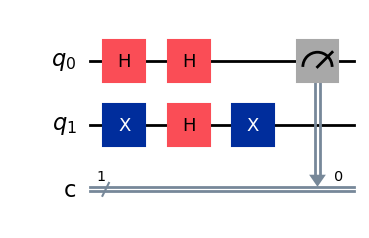

Noiseless: {'0': 1024}
Noiseless result: constant
Noisy: {'0': 1023, '1': 1}
Noisy result: constant


In [29]:
#EXCERCISE 1.3 - Deutch algorithm


case = 4
deutsch_func = deutsch_function(case)


# -----------------------
# NOISELESS VERSION
# -----------------------

qc_ideal = QuantumCircuit(2, 1)

qc_ideal.x(1)
qc_ideal.h(0)
qc_ideal.h(1)

qc_ideal.compose(deutsch_func, inplace=True)

qc_ideal.h(0)
qc_ideal.measure(0, 0)

display(qc_ideal.draw("mpl"))

sampler_ideal = StatevectorSampler()
job_ideal = sampler_ideal.run([qc_ideal], shots=1024)
result_ideal = job_ideal.result()
counts_ideal = result_ideal[0].data.c.get_counts()

print("Noiseless:", counts_ideal)

if counts_ideal.get("0", 0) > counts_ideal.get("1", 0):
    print("Noiseless result: constant")
else:
    print("Noiseless result: balanced")


# -----------------------
# NOISY VERSION
# -----------------------

qc_noisy = qc_ideal.copy()

backend = FakeKyiv()

qc_transpiled = transpile(qc_noisy, backend)


sampler_noisy = SamplerV2(backend)
job_noisy = sampler_noisy.run([qc_transpiled], shots=1024)
result_noisy = job_noisy.result()
counts_noisy = result_noisy[0].data.c.get_counts()

print("Noisy:", counts_noisy)

if counts_noisy.get("0", 0) > counts_noisy.get("1", 0):
    print("Noisy result: constant")
else:
    print("Noisy result: balanced")

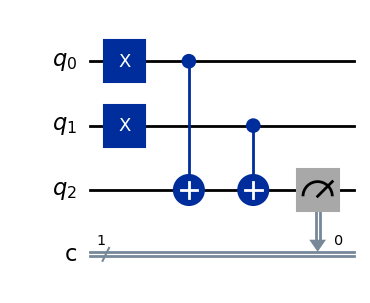

{'0': 1024}


In [ ]:
# DEUTSCH–JOZSA algorithm - EXERCISE 2
# Here we manually evaluate the function f(x0, x1) for a chosen input.
# This does NOT implement the Deutsch–Jozsa algorithm and does NOT determine
# whether the function is constant or balanced. Full classification would
# require checking all possible inputs (00, 01, 10, 11).

qc = QuantumCircuit(3, 1)  # we have 3 qubits: x0, x1 (inputs) and one output qubit

qc.x(0)  # manually set x0 = 1 
qc.x(1)  # manually set x1 = 1 

qc.cx(0, 2)
qc.cx(1, 2)

qc.measure(2, 0)  # measure the output qubit to obtain f(x0, x1)

display(qc.draw('mpl'))

sim = Aer.get_backend('aer_simulator')
qc_compiled = transpile(qc, sim)
job = sim.run(qc_compiled, shots=1024)

result = job.result()
counts = result.get_counts()

print(counts)  

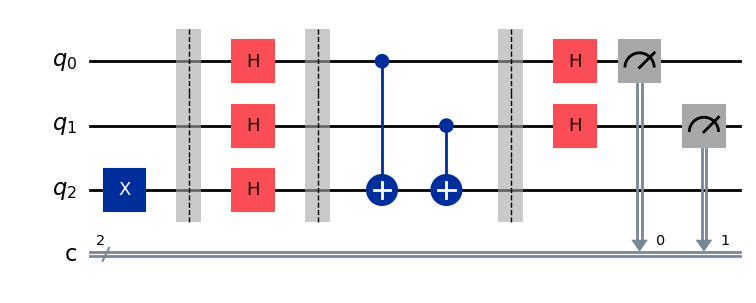

{'11': 1024}


In [ ]:
#Deutsh jozsa algorithm for 2-bit input
qc = QuantumCircuit(3, 2) 
qc.x(2)

qc.barrier()
qc.h(0)
qc.h(1)
qc.h(2)


qc.barrier()
qc.cx(0, 2)
qc.cx(1, 2)
qc.barrier()

qc.h(0)
qc.h(1)

qc.measure(0,0)
qc.measure(1,1)
display(qc.draw('mpl'))

sim = Aer.get_backend('aer_simulator')
qc_compiled = transpile(qc, sim)
job = sim.run(qc_compiled, shots=1024)

result = job.result()
counts = result.get_counts()

print(counts)
